# Business Operations SQL Analytics

### End-to-End Business Intelligence & Decision Analytics Project

This portfolio project demonstrates an end-to-end analytics workflow using **MySQL, SQL, Python, Pandas, NumPy, and Matplotlib** to transform operational business data into actionable management insights.

## Project Objectives

- Analyze revenue, expenses, customers, products/services, and employee performance
- Build executive business KPIs
- Identify revenue concentration and operational risks
- Analyze monthly growth and profitability trends
- Develop and validate a revenue forecasting model
- Compare predictive performance against a baseline model
- Convert analytical findings into management recommendations

## Analytics Framework

**Descriptive → Diagnostic → Predictive → Prescriptive**

The project demonstrates the complete analytics lifecycle from relational database querying through business decision support.

## 1. Database Connection & Validation

This section connects Python to the MySQL `business_operations_analytics` database and verifies that the required relational tables and records are available for analysis.

In [2]:
import pandas as pd
import mysql.connector
from getpass import getpass
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

db_password = getpass("Enter MySQL root password: ")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=db_password,
    database="business_operations_analytics_demo"
)

print("Connected successfully to MySQL.")

Enter MySQL root password:  ········


Connected successfully to MySQL.


In [3]:
query = """
SELECT
    (SELECT COUNT(*) FROM customers) AS customers,
    (SELECT COUNT(*) FROM employees) AS employees,
    (SELECT COUNT(*) FROM products) AS products,
    (SELECT COUNT(*) FROM orders) AS orders,
    (SELECT COUNT(*) FROM order_items) AS order_items,
    (SELECT COUNT(*) FROM payments) AS payments,
    (SELECT COUNT(*) FROM expenses) AS expenses;
"""

df_check = pd.read_sql(query, conn)
df_check

,customers,employees,products,orders,order_items,payments,expenses
0,10,6,10,20,38,20,20


## 2. Executive KPI Analysis

This section summarizes the core business performance indicators, including revenue, expenses, operating surplus, order volume, customer count, average order value, and revenue per customer.

In [4]:
kpi_query = """
SELECT
    (SELECT SUM(total_amount) FROM orders) AS total_revenue,
    (SELECT SUM(amount) FROM expenses) AS total_expenses,
    (SELECT SUM(total_amount) FROM orders)
      - (SELECT SUM(amount) FROM expenses) AS operating_surplus,
    (SELECT COUNT(*) FROM orders) AS total_orders,
    (SELECT COUNT(*) FROM customers) AS total_customers;
"""

kpi = pd.read_sql(kpi_query, conn)

kpi["surplus_margin_pct"] = (
    kpi["operating_surplus"] / kpi["total_revenue"] * 100
).round(2)

kpi

,total_revenue,total_expenses,operating_surplus,total_orders,total_customers,surplus_margin_pct
0,84300.0,27300.0,57000.0,20,10,67.62


## 3. Monthly Financial Performance

This section analyzes monthly revenue, expenses, and operating surplus to identify financial trends and changes over time.

In [5]:
monthly_query = """
SELECT
    m.month,
    m.revenue,
    COALESCE(e.expenses, 0) AS expenses,
    m.revenue - COALESCE(e.expenses, 0) AS operating_surplus
FROM
(
    SELECT
        DATE_FORMAT(order_date, '%Y-%m') AS month,
        SUM(total_amount) AS revenue
    FROM orders
    GROUP BY DATE_FORMAT(order_date, '%Y-%m')
) m
LEFT JOIN
(
    SELECT
        DATE_FORMAT(expense_date, '%Y-%m') AS month,
        SUM(amount) AS expenses
    FROM expenses
    GROUP BY DATE_FORMAT(expense_date, '%Y-%m')
) e
ON m.month = e.month
ORDER BY m.month;
"""

monthly_df = pd.read_sql(monthly_query, conn)
monthly_df

,month,revenue,expenses,operating_surplus
0,2025-01,4400.0,850.0,3550.0
1,2025-02,4100.0,1200.0,2900.0
2,2025-03,3800.0,950.0,2850.0
3,2025-04,4050.0,1800.0,2250.0
4,2025-05,4000.0,1450.0,2550.0
5,2025-06,3750.0,700.0,3050.0
6,2025-07,4700.0,2100.0,2600.0
7,2025-08,4700.0,1250.0,3450.0
8,2025-09,3650.0,1600.0,2050.0
9,2025-10,4800.0,1750.0,3050.0


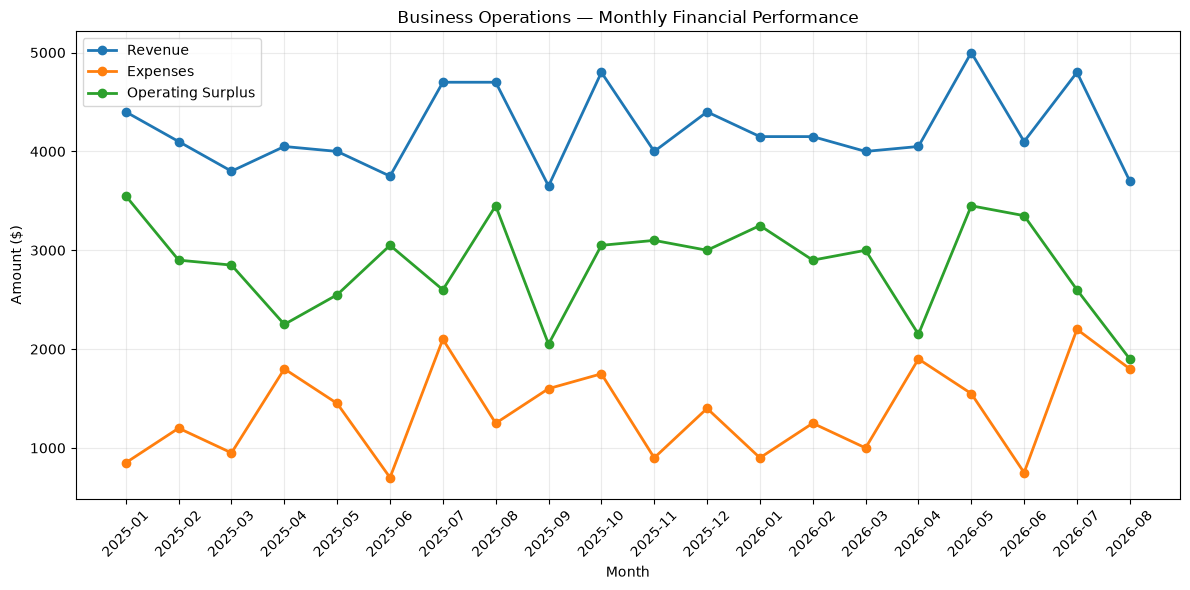

In [6]:
import matplotlib.pyplot as plt

monthly_df["month"] = monthly_df["month"].astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_df["month"],
    monthly_df["revenue"],
    marker="o",
    linewidth=2,
    label="Revenue"
)

plt.plot(
    monthly_df["month"],
    monthly_df["expenses"],
    marker="o",
    linewidth=2,
    label="Expenses"
)

plt.plot(
    monthly_df["month"],
    monthly_df["operating_surplus"],
    marker="o",
    linewidth=2,
    label="Operating Surplus"
)

plt.title("Business Operations — Monthly Financial Performance")
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

## 4. Customer Revenue Analysis

This section evaluates customer-level revenue, order activity, and average order value to identify high-value customers and assess revenue concentration.

In [7]:
customer_query = """
SELECT
    c.customer_id,
    c.customer_name,
    COUNT(DISTINCT o.order_id) AS total_orders,
    SUM(o.total_amount) AS total_revenue,
    ROUND(AVG(o.total_amount), 2) AS avg_order_value
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_id,
    c.customer_name
ORDER BY total_revenue DESC;
"""

customer_df = pd.read_sql(customer_query, conn)

customer_df

,customer_id,customer_name,total_orders,total_revenue,avg_order_value
0,7,BlueSky Logistics,2,9700.0,4850.0
1,8,Summit Professional Services,2,8800.0,4400.0
2,2,Northern Retail Group,2,8500.0,4250.0
3,10,Evergreen Enterprises,2,8500.0,4250.0
4,9,Urban Data Systems,2,8450.0,4225.0
5,1,Maple Tech Solutions,2,8400.0,4200.0
6,4,Capital Office Group,2,8200.0,4100.0
7,5,Metro Business Systems,2,8000.0,4000.0
8,3,Lakeview Services,2,7950.0,3975.0
9,6,Greenfield Consulting,2,7800.0,3900.0


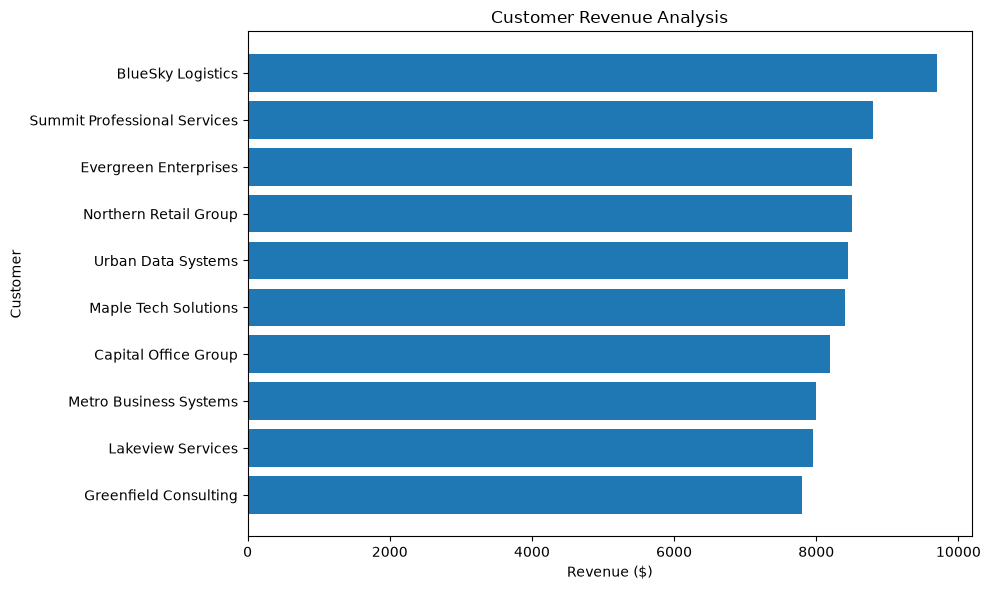

In [8]:
plt.figure(figsize=(10, 6))

customer_chart = customer_df.sort_values(
    "total_revenue",
    ascending=True
)

plt.barh(
    customer_chart["customer_name"],
    customer_chart["total_revenue"]
)

plt.title("Customer Revenue Analysis")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer")
plt.tight_layout()

plt.show()

## 5. Product & Service Revenue Analysis

This section evaluates product and service performance by units sold and revenue generated to identify the strongest contributors to business revenue.

In [9]:
product_query = """
SELECT
    p.product_id,
    p.product_name,
    p.category,
    SUM(oi.quantity) AS units_sold,
    SUM(oi.line_total) AS product_revenue
FROM products p
JOIN order_items oi
    ON p.product_id = oi.product_id
GROUP BY
    p.product_id,
    p.product_name,
    p.category
ORDER BY product_revenue DESC;
"""

product_df = pd.read_sql(product_query, conn)

product_df

,product_id,product_name,category,units_sold,product_revenue
0,2,Business Analytics Package,Analytics,4.0,12800.0
1,1,Database Design Service,Database,5.0,12500.0
2,4,SQL Development Service,Database,5.0,11000.0
3,8,Reporting Automation,Automation,3.0,8400.0
4,7,Analytics Consultation,Consulting,5.0,8000.0
5,5,Data Cleaning Service,Data Management,8.0,7600.0
6,6,Database Optimization,Database,10.0,7500.0
7,3,Power BI Dashboard,Business Intelligence,4.0,7200.0
8,10,Performance Analysis,Analytics,4.0,4800.0
9,9,Data Migration Service,Data Management,10.0,4500.0


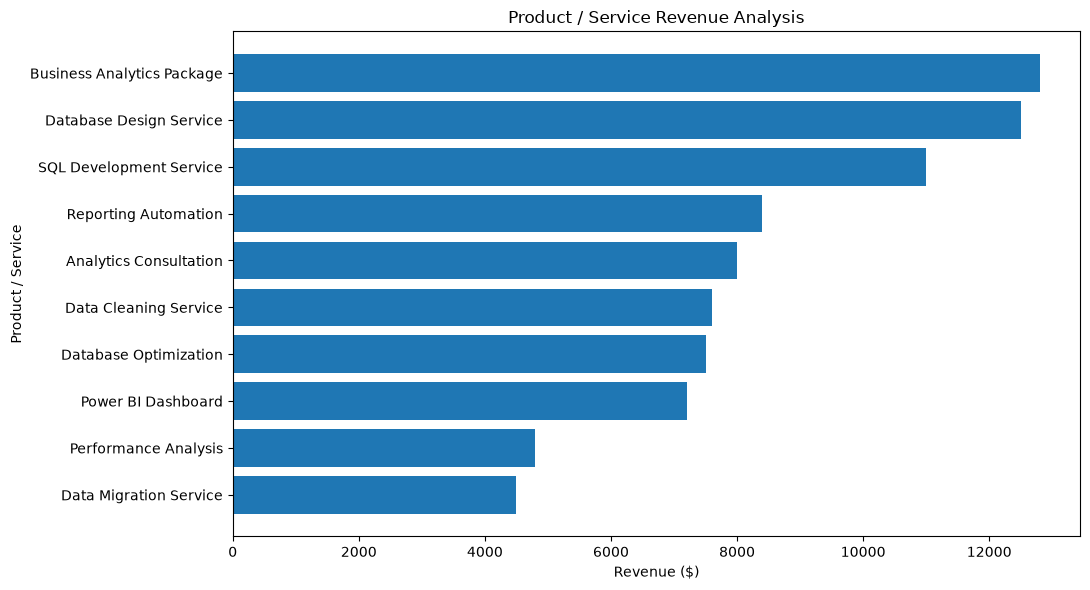

In [10]:
product_chart = product_df.sort_values(
    "product_revenue",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    product_chart["product_name"],
    product_chart["product_revenue"]
)

plt.title("Product / Service Revenue Analysis")
plt.xlabel("Revenue ($)")
plt.ylabel("Product / Service")
plt.tight_layout()

plt.show()

## 6. Employee & Sales Performance

This section analyzes employee-attributed orders and revenue to identify key revenue contributors and potential concentration risk.

In [11]:
employee_query = """
SELECT
    e.employee_id,
    CONCAT(e.first_name, ' ', e.last_name) AS employee_name,
    e.job_title,
    COUNT(o.order_id) AS total_orders,
    COALESCE(SUM(o.total_amount), 0) AS revenue_generated
FROM employees e
LEFT JOIN orders o
    ON e.employee_id = o.employee_id
GROUP BY
    e.employee_id,
    e.first_name,
    e.last_name,
    e.job_title
ORDER BY revenue_generated DESC;
"""

employee_df = pd.read_sql(employee_query, conn)

employee_df


,employee_id,employee_name,job_title,total_orders,revenue_generated
0,2,Sarah Patel,Sales Representative,10,42500.0
1,1,David Chen,Sales Manager,10,41800.0
2,3,Michael Brown,Operations Manager,0,0.0
3,4,Emily Wilson,Financial Analyst,0,0.0
4,5,Daniel Lee,Marketing Specialist,0,0.0
5,6,Priya Sharma,Database Analyst,0,0.0


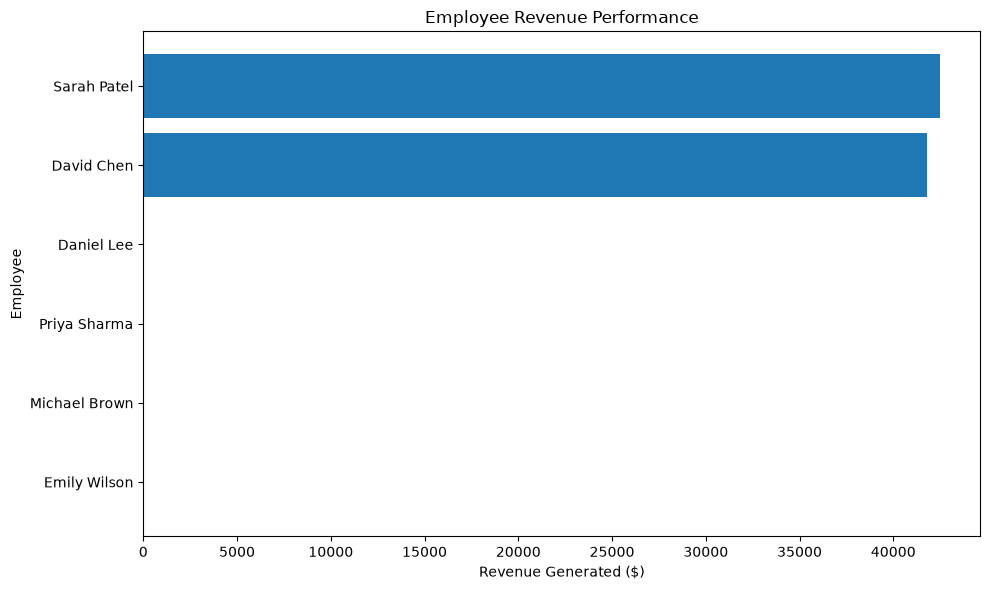

In [12]:
employee_chart = employee_df.sort_values(
    "revenue_generated",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    employee_chart["employee_name"],
    employee_chart["revenue_generated"]
)

plt.title("Employee Revenue Performance")
plt.xlabel("Revenue Generated ($)")
plt.ylabel("Employee")
plt.tight_layout()

plt.show()

In [13]:
# Executive KPI Dashboard

total_revenue = float(kpi["total_revenue"].iloc[0])
total_expenses = float(kpi["total_expenses"].iloc[0])
operating_surplus = float(kpi["operating_surplus"].iloc[0])
total_orders = int(kpi["total_orders"].iloc[0])
total_customers = int(kpi["total_customers"].iloc[0])

surplus_margin = (operating_surplus / total_revenue) * 100
avg_order_value = total_revenue / total_orders
revenue_per_customer = total_revenue / total_customers

print("=" * 55)
print("       BUSINESS OPERATIONS — EXECUTIVE KPI DASHBOARD")
print("=" * 55)

print(f"Total Revenue:          ${total_revenue:,.2f}")
print(f"Total Expenses:         ${total_expenses:,.2f}")
print(f"Operating Surplus:      ${operating_surplus:,.2f}")
print(f"Operating Margin:       {surplus_margin:.2f}%")
print(f"Total Orders:           {total_orders:,}")
print(f"Total Customers:        {total_customers:,}")
print(f"Average Order Value:    ${avg_order_value:,.2f}")
print(f"Revenue per Customer:   ${revenue_per_customer:,.2f}")

print("=" * 55)

       BUSINESS OPERATIONS — EXECUTIVE KPI DASHBOARD
Total Revenue:          $84,300.00
Total Expenses:         $27,300.00
Operating Surplus:      $57,000.00
Operating Margin:       67.62%
Total Orders:           20
Total Customers:        10
Average Order Value:    $4,215.00
Revenue per Customer:   $8,430.00


## 7. Diagnostic Analysis

This section investigates the drivers behind business performance by measuring customer, product/service, and employee revenue concentration, and by identifying operational risk areas.

In [14]:
# Diagnostic Analysis — Revenue Concentration

top_customer_share = (
    customer_df["total_revenue"].iloc[0] / total_revenue * 100
)

top_3_customer_share = (
    customer_df["total_revenue"].head(3).sum() / total_revenue * 100
)

top_product_share = (
    product_df["product_revenue"].iloc[0] / total_revenue * 100
)

top_3_product_share = (
    product_df["product_revenue"].head(3).sum() / total_revenue * 100
)

top_employee_share = (
    employee_df["revenue_generated"].iloc[0] / total_revenue * 100
)

print("=" * 58)
print("          DIAGNOSTIC ANALYSIS — REVENUE CONCENTRATION")
print("=" * 58)

print(f"Top Customer Revenue Share:       {top_customer_share:.2f}%")
print(f"Top 3 Customers Revenue Share:    {top_3_customer_share:.2f}%")
print(f"Top Product Revenue Share:        {top_product_share:.2f}%")
print(f"Top 3 Products Revenue Share:     {top_3_product_share:.2f}%")
print(f"Top Employee Revenue Share:       {top_employee_share:.2f}%")

print("=" * 58)

          DIAGNOSTIC ANALYSIS — REVENUE CONCENTRATION
Top Customer Revenue Share:       11.51%
Top 3 Customers Revenue Share:    32.03%
Top Product Revenue Share:        15.18%
Top 3 Products Revenue Share:     43.06%
Top Employee Revenue Share:       50.42%


In [15]:
# Business Insights & Recommendations

print("=" * 65)
print("        BUSINESS INSIGHTS & MANAGEMENT RECOMMENDATIONS")
print("=" * 65)

print("\n1. CUSTOMER CONCENTRATION")
print(f"   Top customer contributes {top_customer_share:.2f}% of revenue.")
print(f"   Top 3 customers contribute {top_3_customer_share:.2f}%.")
print("   Insight: Revenue is reasonably diversified across customers.")
print("   Recommendation: Maintain retention efforts while expanding")
print("   the customer base to reduce concentration further.")

print("\n2. PRODUCT / SERVICE PERFORMANCE")
print(f"   Top product contributes {top_product_share:.2f}% of revenue.")
print(f"   Top 3 products contribute {top_3_product_share:.2f}%.")
print("   Insight: Several services contribute meaningfully to revenue.")
print("   Recommendation: Prioritize marketing and capacity for the")
print("   strongest services while reviewing lower-performing offerings.")

print("\n3. EMPLOYEE REVENUE CONCENTRATION")
print(f"   Top employee generates {top_employee_share:.2f}% of revenue.")
print("   Insight: Revenue generation is highly concentrated.")
print("   Recommendation: Cross-train sales responsibilities, distribute")
print("   key accounts, and develop additional revenue-producing staff.")

print("\n4. PROFITABILITY")
print(f"   Operating surplus margin is {surplus_margin:.2f}%.")
print("   Insight: Current dataset indicates strong operating profitability.")
print("   Recommendation: Track margins monthly and investigate major")
print("   expense increases before they affect profitability.")

print("\n5. MANAGEMENT PRIORITY")
print("   Primary risk: Employee revenue concentration.")
print("   Primary opportunity: Scale high-performing products/services")
print("   while maintaining a diversified customer portfolio.")

print("\n" + "=" * 65)

        BUSINESS INSIGHTS & MANAGEMENT RECOMMENDATIONS

1. CUSTOMER CONCENTRATION
   Top customer contributes 11.51% of revenue.
   Top 3 customers contribute 32.03%.
   Insight: Revenue is reasonably diversified across customers.
   Recommendation: Maintain retention efforts while expanding
   the customer base to reduce concentration further.

2. PRODUCT / SERVICE PERFORMANCE
   Top product contributes 15.18% of revenue.
   Top 3 products contribute 43.06%.
   Insight: Several services contribute meaningfully to revenue.
   Recommendation: Prioritize marketing and capacity for the
   strongest services while reviewing lower-performing offerings.

3. EMPLOYEE REVENUE CONCENTRATION
   Top employee generates 50.42% of revenue.
   Insight: Revenue generation is highly concentrated.
   Recommendation: Cross-train sales responsibilities, distribute
   key accounts, and develop additional revenue-producing staff.

4. PROFITABILITY
   Operating surplus margin is 67.62%.
   Insight: Current d

In [16]:
# Monthly Revenue Growth Analysis

trend_df = monthly_df.copy()

trend_df["revenue_growth_pct"] = (
    trend_df["revenue"]
    .pct_change() * 100
).round(2)

trend_df["expense_growth_pct"] = (
    trend_df["expenses"]
    .pct_change() * 100
).round(2)

trend_df["surplus_margin_pct"] = (
    trend_df["operating_surplus"] /
    trend_df["revenue"] * 100
).round(2)

print("=" * 70)
print("                 MONTHLY GROWTH & TREND ANALYSIS")
print("=" * 70)

display(
    trend_df[
        [
            "month",
            "revenue",
            "expenses",
            "operating_surplus",
            "revenue_growth_pct",
            "expense_growth_pct",
            "surplus_margin_pct"
        ]
    ]
)

avg_monthly_growth = trend_df["revenue_growth_pct"].mean()
best_month = trend_df.loc[trend_df["revenue"].idxmax()]
worst_month = trend_df.loc[trend_df["revenue"].idxmin()]

print("\nSUMMARY")
print("-" * 70)

print(
    f"Average Monthly Revenue Growth: "
    f"{avg_monthly_growth:.2f}%"
)

print(
    f"Highest Revenue Month: "
    f"{best_month['month']} "
    f"(${best_month['revenue']:,.2f})"
)

print(
    f"Lowest Revenue Month: "
    f"{worst_month['month']} "
    f"(${worst_month['revenue']:,.2f})"
)

print("=" * 70)

                 MONTHLY GROWTH & TREND ANALYSIS


,month,revenue,expenses,operating_surplus,revenue_growth_pct,expense_growth_pct,surplus_margin_pct
0,2025-01,4400.0,850.0,3550.0,NaN,NaN,80.68
1,2025-02,4100.0,1200.0,2900.0,-6.82,41.18,70.73
2,2025-03,3800.0,950.0,2850.0,-7.32,-20.83,75.00
3,2025-04,4050.0,1800.0,2250.0,6.58,89.47,55.56
4,2025-05,4000.0,1450.0,2550.0,-1.23,-19.44,63.75
5,2025-06,3750.0,700.0,3050.0,-6.25,-51.72,81.33
6,2025-07,4700.0,2100.0,2600.0,25.33,200.00,55.32
7,2025-08,4700.0,1250.0,3450.0,0.00,-40.48,73.40
8,2025-09,3650.0,1600.0,2050.0,-22.34,28.00,56.16
9,2025-10,4800.0,1750.0,3050.0,31.51,9.38,63.54



SUMMARY
----------------------------------------------------------------------
Average Monthly Revenue Growth: 0.23%
Highest Revenue Month: 2026-05 ($5,000.00)
Lowest Revenue Month: 2025-09 ($3,650.00)


## 8. Predictive Analysis

This section develops a revenue forecasting model using historical monthly performance data to estimate near-term revenue trends and support planning decisions.

In [17]:
# Predictive Analysis — Revenue Forecast

import numpy as np

forecast_df = trend_df.copy()

# Numeric time index
forecast_df["time_index"] = np.arange(len(forecast_df))

# Fit linear trend
slope, intercept = np.polyfit(
    forecast_df["time_index"],
    forecast_df["revenue"],
    1
)

# Forecast next 4 months
future_index = np.arange(
    len(forecast_df),
    len(forecast_df) + 4
)

future_revenue = slope * future_index + intercept

future_months = pd.date_range(
    start="2026-09-01",
    periods=4,
    freq="MS"
).strftime("%Y-%m")

revenue_forecast = pd.DataFrame({
    "month": future_months,
    "forecast_revenue": future_revenue.round(2)
})

print("=" * 60)
print("              PREDICTIVE REVENUE FORECAST")
print("=" * 60)

print(f"\nEstimated Monthly Trend: ${slope:,.2f}")
print("\nNext 4 Months Forecast:\n")

display(revenue_forecast)

print("=" * 60)


              PREDICTIVE REVENUE FORECAST

Estimated Monthly Trend: $9.85

Next 4 Months Forecast:



,month,forecast_revenue
0,2026-09,4318.42
1,2026-10,4328.27
2,2026-11,4338.12
3,2026-12,4347.97


In [18]:
# Predictive Model Validation — Holdout Test

actual = forecast_df["revenue"].astype(float).to_numpy()

# Use first 16 months for training
train_size = 16

train_y = actual[:train_size]
test_y = actual[train_size:]

train_x = np.arange(train_size)
test_x = np.arange(train_size, len(actual))

# Train linear model only on historical training data
val_slope, val_intercept = np.polyfit(
    train_x,
    train_y,
    1
)

# Predict the 4 held-out months
test_predictions = (
    val_slope * test_x + val_intercept
)

validation_df = pd.DataFrame({
    "month": forecast_df["month"].iloc[train_size:].values,
    "actual_revenue": test_y,
    "predicted_revenue": test_predictions.round(2)
})

validation_df["absolute_error"] = (
    validation_df["actual_revenue"] -
    validation_df["predicted_revenue"]
).abs().round(2)

validation_df["percentage_error"] = (
    validation_df["absolute_error"] /
    validation_df["actual_revenue"] * 100
).round(2)

mae = validation_df["absolute_error"].mean()
mape = validation_df["percentage_error"].mean()

print("=" * 65)
print("             FORECAST MODEL VALIDATION")
print("=" * 65)

display(validation_df)

print(f"\nMean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

print("\nMODEL INTERPRETATION")

if mape < 10:
    print("Forecast accuracy: STRONG")
elif mape < 20:
    print("Forecast accuracy: MODERATE")
else:
    print("Forecast accuracy: WEAK")

print("=" * 65)

             FORECAST MODEL VALIDATION


,month,actual_revenue,predicted_revenue,absolute_error,percentage_error
0,2026-05,5000.0,4187.50,812.50,16.25
1,2026-06,4100.0,4189.71,89.71,2.19
2,2026-07,4800.0,4191.91,608.09,12.67
3,2026-08,3700.0,4194.12,494.12,13.35



Mean Absolute Error (MAE):  $501.11
Mean Absolute Percentage Error (MAPE): 11.12%

MODEL INTERPRETATION
Forecast accuracy: MODERATE


## 9. Forecast Validation & Model Comparison

This section evaluates predictive accuracy using holdout testing and compares the linear trend model against a naive baseline using MAE and MAPE.

In [19]:
# Forecast Model Comparison — Linear Trend vs Naive Baseline
# Naive forecast:
# predict every future month using the last known training-month revenue
naive_prediction = train_y[-1]

naive_predictions = np.repeat(
    naive_prediction,
    len(test_y)
)

comparison_df = pd.DataFrame({
    "month": forecast_df["month"].iloc[train_size:].values,
    "actual_revenue": test_y,
    "linear_prediction": test_predictions.round(2),
    "naive_prediction": naive_predictions.round(2)
})

comparison_df["linear_abs_error"] = (
    comparison_df["actual_revenue"] -
    comparison_df["linear_prediction"]
).abs()

comparison_df["naive_abs_error"] = (
    comparison_df["actual_revenue"] -
    comparison_df["naive_prediction"]
).abs()

linear_mae = comparison_df["linear_abs_error"].mean()
naive_mae = comparison_df["naive_abs_error"].mean()

linear_mape = (
    comparison_df["linear_abs_error"] /
    comparison_df["actual_revenue"] * 100
).mean()

naive_mape = (
    comparison_df["naive_abs_error"] /
    comparison_df["actual_revenue"] * 100
).mean()

print("=" * 68)
print("              FORECAST MODEL COMPARISON")
print("=" * 68)

display(comparison_df)

print("\nLINEAR TREND MODEL")
print(f"MAE:  ${linear_mae:,.2f}")
print(f"MAPE: {linear_mape:.2f}%")

print("\nNAIVE BASELINE MODEL")
print(f"MAE:  ${naive_mae:,.2f}")
print(f"MAPE: {naive_mape:.2f}%")

print("\nMODEL SELECTION")

if linear_mape < naive_mape:
    print("WINNER: Linear Trend Model")
    print("Reason: Lower holdout MAPE than the naive baseline.")
elif naive_mape < linear_mape:
    print("WINNER: Naive Baseline Model")
    print("Reason: Lower holdout MAPE than the linear trend model.")
else:
    print("RESULT: Models are tied.")

print("=" * 68)

              FORECAST MODEL COMPARISON


,month,actual_revenue,linear_prediction,naive_prediction,linear_abs_error,naive_abs_error
0,2026-05,5000.0,4187.50,4050.0,812.50,950.0
1,2026-06,4100.0,4189.71,4050.0,89.71,50.0
2,2026-07,4800.0,4191.91,4050.0,608.09,750.0
3,2026-08,3700.0,4194.12,4050.0,494.12,350.0



LINEAR TREND MODEL
MAE:  $501.11
MAPE: 11.12%

NAIVE BASELINE MODEL
MAE:  $525.00
MAPE: 11.33%

MODEL SELECTION
WINNER: Linear Trend Model
Reason: Lower holdout MAPE than the naive baseline.


## 10. Prescriptive Analysis & Management Recommendations

This section converts analytical findings into practical management actions focused on revenue growth, customer diversification, product strategy, employee risk, profitability control, and forecasting policy.

In [20]:
# Prescriptive Analysis — Management Action Plan

forecast_avg = revenue_forecast["forecast_revenue"].mean()

current_avg_revenue = trend_df["revenue"].mean()

forecast_change_pct = (
    (forecast_avg - current_avg_revenue) /
    current_avg_revenue * 100
)

print("=" * 68)
print("            PRESCRIPTIVE ANALYSIS — ACTION PLAN")
print("=" * 68)

print(f"\nSelected Forecast Model: Linear Trend Model")
print(f"Holdout MAPE: {linear_mape:.2f}%")

print(f"\nHistorical Average Monthly Revenue: ${current_avg_revenue:,.2f}")
print(f"Forecast Average Monthly Revenue:   ${forecast_avg:,.2f}")
print(f"Forecast vs Historical Average:     {forecast_change_pct:.2f}%")

print("\nMANAGEMENT ACTIONS")
print("-" * 68)

print("1. REVENUE GROWTH")
if forecast_change_pct > 3:
    print("   Forecast indicates meaningful revenue growth.")
    print("   Action: Prepare additional delivery capacity and sales support.")
elif forecast_change_pct < -3:
    print("   Forecast indicates potential revenue weakness.")
    print("   Action: Increase customer outreach, renewals, and lead generation.")
else:
    print("   Forecast indicates relatively stable revenue.")
    print("   Action: Focus on targeted growth rather than major expansion.")

print("\n2. CUSTOMER STRATEGY")
print(f"   Top 3 customers represent {top_3_customer_share:.2f}% of revenue.")
print("   Action: Protect key accounts while continuing customer diversification.")

print("\n3. PRODUCT / SERVICE STRATEGY")
print(f"   Top 3 products represent {top_3_product_share:.2f}% of revenue.")
print("   Action: Invest sales and delivery resources in high-performing services.")
print("   Review low-revenue offerings for pricing, repositioning, or bundling.")

print("\n4. EMPLOYEE RISK")
print(f"   Top employee accounts for {top_employee_share:.2f}% of revenue.")
print("   Action: Cross-train staff, distribute customer relationships,")
print("   and reduce dependence on a single revenue-generating employee.")

print("\n5. PROFITABILITY CONTROL")
print(f"   Current operating margin: {surplus_margin:.2f}%.")
print("   Action: Set monthly expense and margin alerts to identify deterioration early.")

print("\n6. FORECASTING POLICY")
print(f"   Model MAPE is {linear_mape:.2f}%.")
print("   Action: Treat forecasts as planning estimates, not guaranteed outcomes.")
print("   Re-train the model as additional monthly data becomes available.")

print("\n" + "=" * 68)

            PRESCRIPTIVE ANALYSIS — ACTION PLAN

Selected Forecast Model: Linear Trend Model
Holdout MAPE: 11.12%

Historical Average Monthly Revenue: $4,215.00
Forecast Average Monthly Revenue:   $4,333.20
Forecast vs Historical Average:     2.80%

MANAGEMENT ACTIONS
--------------------------------------------------------------------
1. REVENUE GROWTH
   Forecast indicates relatively stable revenue.
   Action: Focus on targeted growth rather than major expansion.

2. CUSTOMER STRATEGY
   Top 3 customers represent 32.03% of revenue.
   Action: Protect key accounts while continuing customer diversification.

3. PRODUCT / SERVICE STRATEGY
   Top 3 products represent 43.06% of revenue.
   Action: Invest sales and delivery resources in high-performing services.
   Review low-revenue offerings for pricing, repositioning, or bundling.

4. EMPLOYEE RISK
   Top employee accounts for 50.42% of revenue.
   Action: Cross-train staff, distribute customer relationships,
   and reduce dependence on